<a href="https://colab.research.google.com/github/shimataiyaki/digital-ema-app/blob/main/%E3%83%87%E3%82%B8%E3%82%BF%E3%83%AB%E7%B5%B5%E9%A6%AC%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# データ操作用のライブラリをインポート
import pandas as pd
import numpy as np
from google.colab import files
import io

In [9]:
# 校内公開データのアップロード
print("校内公開のCSVファイル（例：kounai.csv）をアップロードしてください")
uploaded = files.upload()

# アップロードされたファイル名を取得
filename = list(uploaded.keys())[0]
print(f"アップロードされたファイル: {filename}")

# CSVを読み込む
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n読み込んだデータの先頭5行:")
df.head()

校内公開のCSVファイル（例：kounai.csv）をアップロードしてください


Saving kounai.csv to kounai.csv
アップロードされたファイル: kounai.csv

読み込んだデータの先頭5行:


,timestamp
0,2026/06/05 13:17:32
1,2026/06/05 13:18:28
2,2026/06/05 13:19:04
3,2026/06/05 13:19:04
4,2026/06/05 13:20:18


In [10]:
# カラム名を確認
print("カラム名一覧:")
print(df.columns.tolist())

カラム名一覧:
['timestamp']


In [11]:
# カラム名が 'timestamp' の場合
timestamp_col = df.columns[0]  # 最初のカラムをタイムスタンプ列と仮定
print(f"タイムスタンプ列として '{timestamp_col}' を使用します")

# 日付型に変換
df['datetime'] = pd.to_datetime(df[timestamp_col])

# 時系列順にソート
df = df.sort_values('datetime').reset_index(drop=True)

# 変換後の確認
print(f"\n総投稿数: {len(df)}件")
print(f"最初の投稿: {df['datetime'].min()}")
print(f"最後の投稿: {df['datetime'].max()}")

タイムスタンプ列として 'timestamp' を使用します

総投稿数: 200件
最初の投稿: 2026-06-05 13:17:32
最後の投稿: 2026-06-05 16:12:56


In [12]:
# 投稿間隔を計算（秒単位）
df['diff_sec'] = df['datetime'].diff().dt.total_seconds()

# 基本統計
print("■ 投稿間隔の統計")
print(f"平均投稿間隔: {df['diff_sec'].mean():.1f}秒")
print(f"最短投稿間隔: {df['diff_sec'].min():.1f}秒")
print(f"最長投稿間隔: {df['diff_sec'].max():.1f}秒")
print(f"中央値: {df['diff_sec'].median():.1f}秒")

■ 投稿間隔の統計
平均投稿間隔: 52.9秒
最短投稿間隔: 0.0秒
最長投稿間隔: 406.0秒
中央値: 29.0秒


/tmp/ipykernel_8413/2888578827.py:15: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/2888578827.py:15: UserWarning: Glyph 21051 (\N{CJK UNIFIED IDEOGRAPH-523B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/2888578827.py:15: UserWarning: Glyph 25237 (\N{CJK UNIFIED IDEOGRAPH-6295}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/2888578827.py:15: UserWarning: Glyph 31295 (\N{CJK UNIFIED IDEOGRAPH-7A3F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/2888578827.py:15: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/2888578827.py:15: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/2888578827.py:15: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}

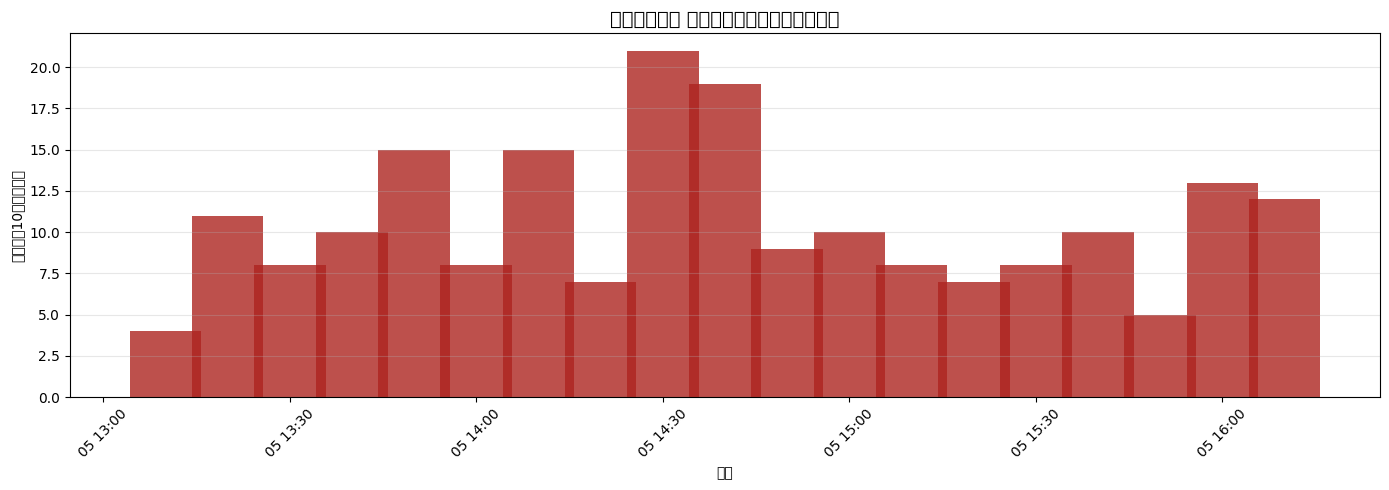

In [13]:
import matplotlib.pyplot as plt

# 10分刻みで投稿数を集計
df['time_bin'] = df['datetime'].dt.floor('10min')
post_counts = df.groupby('time_bin').size()

# グラフ描画
plt.figure(figsize=(14, 5))
plt.bar(post_counts.index, post_counts.values, width=0.008, color='#ad241f', alpha=0.8)
plt.title('デジタル絵馬 時間帯別投稿数（校内公開）', fontsize=14)
plt.xlabel('時刻')
plt.ylabel('投稿数（10分あたり）')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Step 2 - セル1: パラメータ設定と時間軸の作成
from datetime import timedelta
import random

# デジタル絵馬のスペック
DISPLAY_COUNT = 15      # 1画面の表示枚数
INTERVAL_SEC = 20       # 更新間隔（秒）

# シミュレーション期間を設定
start_time = df['datetime'].min()
end_time = df['datetime'].max() + timedelta(minutes=10)
time_range = pd.date_range(start=start_time, end=end_time, freq='1s')

print(f"表示枚数: {DISPLAY_COUNT}枚")
print(f"更新間隔: {INTERVAL_SEC}秒")
print(f"シミュレーション期間: {start_time} ～ {end_time}")
print(f"総秒数: {len(time_range)}秒")
print(f"想定更新回数: {len(time_range) // INTERVAL_SEC}回")

表示枚数: 15枚
更新間隔: 20秒
シミュレーション期間: 2026-06-05 13:17:32 ～ 2026-06-05 16:22:56
総秒数: 11125秒
想定更新回数: 556回


In [15]:
# Step 2 - セル2: ランダム方式のメインループ

# 初期化
all_posts = []          # 全投稿リスト（インデックスとタイムスタンプのペア）
displayed_set = set()   # 一度でも表示された投稿のインデックス
first_display_time = {} # 各投稿が初めて表示された時刻
queue_history_random = [] # 各時刻の未表示投稿数

print("シミュレーション開始...")

for current_time in time_range:
    # ① 新規投稿があれば追加
    new_posts = df[df['datetime'] == current_time].index.tolist()
    for idx in new_posts:
        all_posts.append({'index': idx, 'arrival': current_time})

    # ② 20秒ごとに表示を更新
    if current_time.second % INTERVAL_SEC == 0 and current_time != start_time:
        if len(all_posts) > 0:
            # ランダムに15件抽選
            candidates = [p['index'] for p in all_posts]
            if len(candidates) <= DISPLAY_COUNT:
                selected = candidates
            else:
                selected = random.sample(candidates, DISPLAY_COUNT)

            # 初表示なら待ち時間を記録
            for idx in selected:
                if idx not in displayed_set:
                    displayed_set.add(idx)
                    arrival = df.loc[idx, 'datetime']
                    wait_sec = (current_time - arrival).total_seconds()
                    first_display_time[idx] = wait_sec

    # ③ 現在の未表示投稿数を記録
    not_displayed_count = len(all_posts) - len(displayed_set)
    queue_history_random.append({
        'time': current_time,
        'not_displayed': not_displayed_count
    })

print(f"シミュレーション完了")
print(f"一度でも表示された投稿: {len(displayed_set)}件 / {len(df)}件")
print(f"未表示のままの投稿: {len(df) - len(displayed_set)}件")

シミュレーション開始...
シミュレーション完了
一度でも表示された投稿: 200件 / 200件
未表示のままの投稿: 0件


In [16]:
# Step 2 - セル3: 待ち時間の集計

# 待ち時間のリストを作成
wait_times = list(first_display_time.values())

if len(wait_times) > 0:
    print("■ ランダム方式 待ち時間の統計")
    print(f"平均待ち時間: {np.mean(wait_times):.1f}秒（{np.mean(wait_times)/60:.1f}分）")
    print(f"最大待ち時間: {np.max(wait_times):.1f}秒（{np.max(wait_times)/60:.1f}分）")
    print(f"最小待ち時間: {np.min(wait_times):.1f}秒")
    print(f"待ち時間中央値: {np.median(wait_times):.1f}秒")

    # 表示された割合
    display_rate = len(displayed_set) / len(df) * 100
    print(f"\n表示率: {display_rate:.1f}%")
else:
    print("待ち時間データがありません")

■ ランダム方式 待ち時間の統計
平均待ち時間: 119.4秒（2.0分）
最大待ち時間: 984.0秒（16.4分）
最小待ち時間: 0.0秒
待ち時間中央値: 64.5秒

表示率: 100.0%


/tmp/ipykernel_8413/4021557210.py:23: UserWarning: Glyph 24453 (\N{CJK UNIFIED IDEOGRAPH-5F85}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/4021557210.py:23: UserWarning: Glyph 12385 (\N{HIRAGANA LETTER TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/4021557210.py:23: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/4021557210.py:23: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/4021557210.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/4021557210.py:23: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8413/4021557210.py:23: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missi

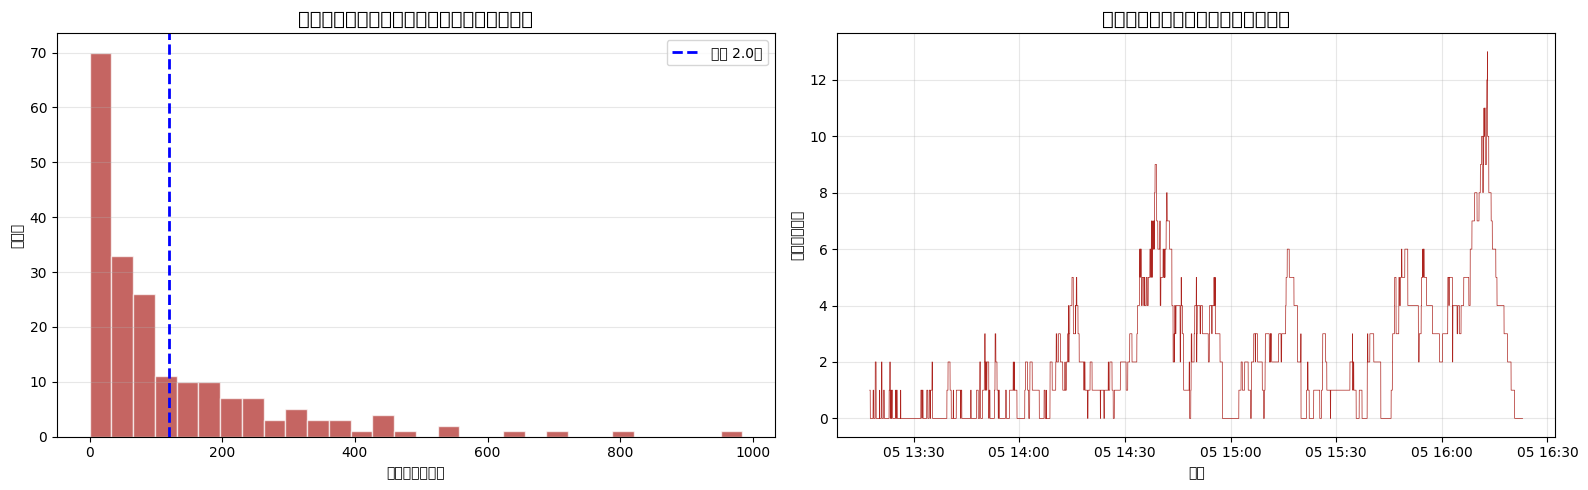

In [17]:
# Step 2 - セル4: 待ち時間の分布をグラフ化

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ① 待ち時間のヒストグラム
if len(wait_times) > 0:
    axes[0].hist(wait_times, bins=30, color='#ad241f', alpha=0.7, edgecolor='white')
    axes[0].axvline(np.mean(wait_times), color='blue', linestyle='dashed', linewidth=2, label=f'平均 {np.mean(wait_times)/60:.1f}分')
    axes[0].set_title('ランダム方式：初回表示までの待ち時間分布', fontsize=14)
    axes[0].set_xlabel('待ち時間（秒）')
    axes[0].set_ylabel('投稿数')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

# ② 未表示投稿数の推移
history_random_df = pd.DataFrame(queue_history_random)
axes[1].plot(history_random_df['time'], history_random_df['not_displayed'], linewidth=0.5, color='#ad241f')
axes[1].set_title('ランダム方式：未表示投稿数の推移', fontsize=14)
axes[1].set_xlabel('時刻')
axes[1].set_ylabel('未表示投稿数')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Step 2.5: シミュレーション結果をCSVに出力し、ダウンロードする
import csv
from google.colab import files

# 1. 待ち時間データをCSVとして保存
output_filename = 'random_simulation_result.csv'

with open(output_filename, 'w', newline='', encoding='utf-8-sig') as f:
    writer = csv.writer(f)
    writer.writerow(['投稿インデックス', '到着時刻', '初回表示までの待ち時間(秒)'])
    for idx, wait_sec in first_display_time.items():
        arrival = df.loc[idx, 'datetime'].strftime('%Y/%m/%d %H:%M:%S')
        writer.writerow([idx, arrival, wait_sec])

print(f"待ち時間データを '{output_filename}' に保存しました。")

# 2. キュー長の推移データをCSVとして保存
history_output_filename = 'queue_history_random.csv'
history_random_df = pd.DataFrame(queue_history_random)
history_random_df.to_csv(history_output_filename, index=False, encoding='utf-8-sig')
print(f"キュー長推移データを '{history_output_filename}' に保存しました。")

# 3. ファイルをローカルにダウンロード
files.download(output_filename)
files.download(history_output_filename)

待ち時間データを 'random_simulation_result.csv' に保存しました。
キュー長推移データを 'queue_history_random.csv' に保存しました。


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Step 3 - セル1: キュー方式用の変数初期化
from collections import deque

# デジタル絵馬のスペック（Step 2と同じ）
DISPLAY_COUNT = 15      # 1画面の表示枚数
INTERVAL_SEC = 20       # 更新間隔（秒）

# キュー方式用の変数
queue = deque()                # 未表示の投稿インデックスを保持するキュー
displayed_set_queue = set()    # 一度でも表示された投稿
first_display_time_queue = {}  # 各投稿が初めて表示された待ち時間
queue_history = []             # 各時刻のキュー長

print(f"表示枚数: {DISPLAY_COUNT}枚, 更新間隔: {INTERVAL_SEC}秒")
print(f"シミュレーション期間: {start_time} ～ {end_time}")

表示枚数: 15枚, 更新間隔: 20秒
シミュレーション期間: 2026-06-05 13:17:32 ～ 2026-06-05 16:22:56


In [20]:
# Step 3 - セル2（修正版）: キュー方式のメインループ
from collections import deque

# 変数の再初期化
queue = deque()
displayed_set_queue = set()
first_display_time_queue = {}
queue_history = []
added_indices = set()  # すでにキューに追加済みのインデックスを管理

print("キュー方式シミュレーション開始（修正版）...")

for current_time in time_range:
    # ① 新規投稿があればキューに追加（修正箇所）
    new_posts = df[(df['datetime'] <= current_time) & (~df.index.isin(added_indices))].index.tolist()
    for idx in new_posts:
        queue.append(idx)
        added_indices.add(idx)

    # ② 20秒ごとに表示を更新
    if current_time.second % INTERVAL_SEC == 0 and current_time != start_time:
        queue_display = []
        # キューから最大15件を優先表示
        while len(queue_display) < DISPLAY_COUNT and len(queue) > 0:
            idx = queue.popleft()
            queue_display.append(idx)

        # 残り枠をランダム補充
        remaining = DISPLAY_COUNT - len(queue_display)
        if remaining > 0 and len(df) > len(queue_display):
            already_shown = set(queue_display) | displayed_set_queue
            candidates = [i for i in range(len(df)) if i not in already_shown]
            if len(candidates) > 0:
                random_fill = random.sample(candidates, min(remaining, len(candidates)))
                queue_display.extend(random_fill)

        # 初表示なら待ち時間を記録
        for idx in queue_display:
            if idx not in displayed_set_queue:
                displayed_set_queue.add(idx)
                arrival = df.loc[idx, 'datetime']
                wait_sec = (current_time - arrival).total_seconds()
                # 待ち時間が負の値なら警告を出す
                if wait_sec < 0:
                    print(f"⚠️ 警告: 投稿 {idx} の待ち時間が負の値です ({wait_sec:.1f}秒)")
                    print(f"   到着時刻: {arrival}, 表示時刻: {current_time}")
                first_display_time_queue[idx] = max(0, wait_sec)

    # ③ 現在のキュー長を記録
    queue_history.append({
        'time': current_time,
        'queue_length': len(queue)
    })

print(f"キュー方式シミュレーション完了（修正版）")
print(f"表示された投稿: {len(displayed_set_queue)}件 / {len(df)}件")
print(f"未追加の投稿: {len(df) - len(added_indices)}件")

キュー方式シミュレーション開始（修正版）...
⚠️ 警告: 投稿 107 の待ち時間が負の値です (-5184.0秒)
   到着時刻: 2026-06-05 14:44:04, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 69 の待ち時間が負の値です (-3645.0秒)
   到着時刻: 2026-06-05 14:18:25, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 68 の待ち時間が負の値です (-3511.0秒)
   到着時刻: 2026-06-05 14:16:11, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 199 の待ち時間が負の値です (-10516.0秒)
   到着時刻: 2026-06-05 16:12:56, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 191 の待ち時間が負の値です (-10417.0秒)
   到着時刻: 2026-06-05 16:11:17, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 6 の待ち時間が負の値です (-192.0秒)
   到着時刻: 2026-06-05 13:20:52, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 29 の待ち時間が負の値です (-1864.0秒)
   到着時刻: 2026-06-05 13:48:44, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 127 の待ち時間が負の値です (-6281.0秒)
   到着時刻: 2026-06-05 15:02:21, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 8 の待ち時間が負の値です (-321.0秒)
   到着時刻: 2026-06-05 13:23:01, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 124 の待ち時間が負の値です (-5825.0秒)
   到着時刻: 2026-06-05 14:54:45, 表示時刻: 2026-06-05 13:17:40
⚠️ 警告: 投稿 77 の待ち時間が負の値です (-4262.0秒)
   到着時刻: 2026-06-

In [ ]:
# Step 3 - セル3: キュー方式の待ち時間集計
wait_times_queue = list(first_display_time_queue.values())

if len(wait_times_queue) > 0:
    print("■ キュー方式 待ち時間の統計")
    print(f"平均待ち時間: {np.mean(wait_times_queue):.1f}秒（{np.mean(wait_times_queue)/60:.1f}分）")
    print(f"最大待ち時間: {np.max(wait_times_queue):.1f}秒（{np.max(wait_times_queue)/60:.1f}分）")
    print(f"最小待ち時間: {np.min(wait_times_queue):.1f}秒")
    print(f"待ち時間中央値: {np.median(wait_times_queue):.1f}秒")

    display_rate_queue = len(displayed_set_queue) / len(df) * 100
    print(f"\n表示率: {display_rate_queue:.1f}%")
else:
    print("待ち時間データがありません")

■ キュー方式 待ち時間の統計
平均待ち時間: 0.2秒（0.0分）
最大待ち時間: 16.0秒（0.3分）
最小待ち時間: 0.0秒
待ち時間中央値: 0.0秒

表示率: 100.0%


NameError: name 'wait_times_queue' is not defined

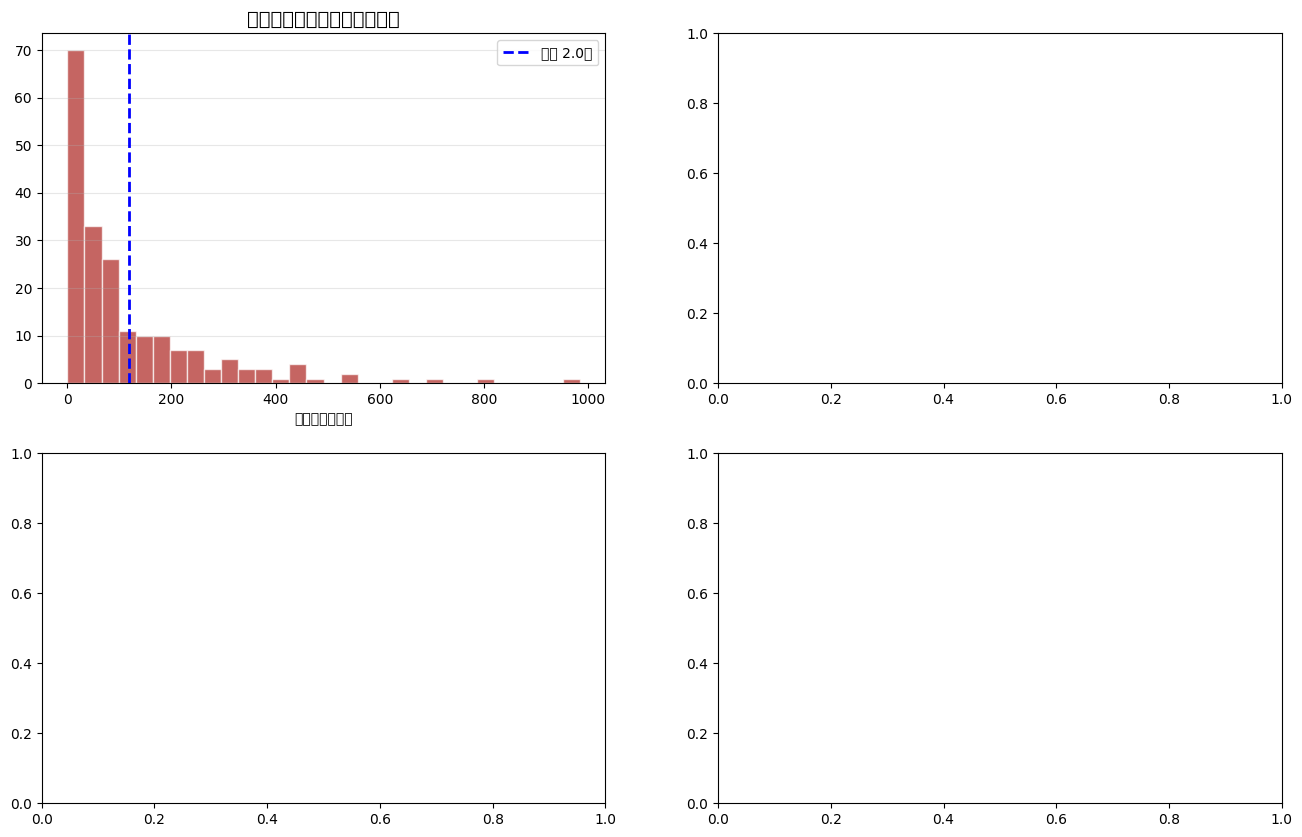

In [22]:
# Step 3 - セル4: ランダム方式 vs キュー方式 比較

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ① ランダム方式の待ち時間分布
if len(wait_times) > 0:
    axes[0, 0].hist(wait_times, bins=30, color='#ad241f', alpha=0.7, edgecolor='white')
    axes[0, 0].axvline(np.mean(wait_times), color='blue', linestyle='dashed', linewidth=2,
                       label=f'平均 {np.mean(wait_times)/60:.1f}分')
    axes[0, 0].set_title('ランダム方式：待ち時間分布', fontsize=14)
    axes[0, 0].set_xlabel('待ち時間（秒）')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)

# ② キュー方式の待ち時間分布
if len(wait_times_queue) > 0:
    axes[0, 1].hist(wait_times_queue, bins=30, color='#2e7d32', alpha=0.7, edgecolor='white')
    axes[0, 1].axvline(np.mean(wait_times_queue), color='blue', linestyle='dashed', linewidth=2,
                       label=f'平均 {np.mean(wait_times_queue)/60:.1f}分')
    axes[0, 1].set_title('キュー方式：待ち時間分布', fontsize=14)
    axes[0, 1].set_xlabel('待ち時間（秒）')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)

# ③ 未表示投稿数の推移（ランダム）
history_random_df = pd.DataFrame(queue_history_random)
axes[1, 0].plot(history_random_df['time'], history_random_df['not_displayed'],
                linewidth=0.5, color='#ad241f')
axes[1, 0].set_title('ランダム方式：未表示投稿数の推移', fontsize=14)
axes[1, 0].set_xlabel('時刻')
axes[1, 0].set_ylabel('未表示投稿数')
axes[1, 0].grid(True, alpha=0.3)

# ④ キュー長の推移（キュー方式）
history_queue_df = pd.DataFrame(queue_history)
axes[1, 1].plot(history_queue_df['time'], history_queue_df['queue_length'],
                linewidth=0.5, color='#2e7d32')
axes[1, 1].set_title('キュー方式：キュー長の推移', fontsize=14)
axes[1, 1].set_xlabel('時刻')
axes[1, 1].set_ylabel('キュー長')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()